In [2]:
# Importing the dependent modules
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
%matplotlib inline

In [16]:
# laoding the data to a pandas dataframe
df = pd.read_csv("HR_data.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [17]:
df.shape

(14999, 10)

In [18]:
left = df[df.left==1]
left.shape

(3571, 10)

In [19]:
retained = df[df.left==0]
retained.shape

(11428, 10)

In [22]:
# THis dataset is highly imbalanced so take equal sized retaied value
retained = retained.sample(n=3571, random_state=2)

In [23]:
retained.shape

(3571, 10)

In [24]:
df = pd.concat([left, retained])
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [25]:
df.shape

(7142, 10)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7142 entries, 0 to 4751
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     7142 non-null   float64
 1   last_evaluation        7142 non-null   float64
 2   number_project         7142 non-null   int64  
 3   average_montly_hours   7142 non-null   int64  
 4   time_spend_company     7142 non-null   int64  
 5   Work_accident          7142 non-null   int64  
 6   left                   7142 non-null   int64  
 7   promotion_last_5years  7142 non-null   int64  
 8   Department             7142 non-null   object 
 9   salary                 7142 non-null   object 
dtypes: float64(2), int64(6), object(2)
memory usage: 613.8+ KB


In [27]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,7142.000000,7142.000000,7142.000000,7142.000000,7142.000000,7142.000000,7142.000000,7142.000000
mean,0.555244,0.717064,3.825399,203.206665,3.617334,0.109213,0.500000,0.017082
std,0.267394,0.180383,1.460744,53.821492,1.301017,0.311928,0.500035,0.129586
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.380000,0.540000,2.000000,152.000000,3.000000,0.000000,0.000000,0.000000
50%,0.560000,0.730000,4.000000,203.000000,3.000000,0.000000,0.500000,0.000000
75%,0.790000,0.880000,5.000000,252.000000,4.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [28]:
df.groupby("left").mean(numeric_only=1)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.670389,0.716015,3.795295,198.994119,3.358163,0.171101,0.028843
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


<Axes: xlabel='salary'>

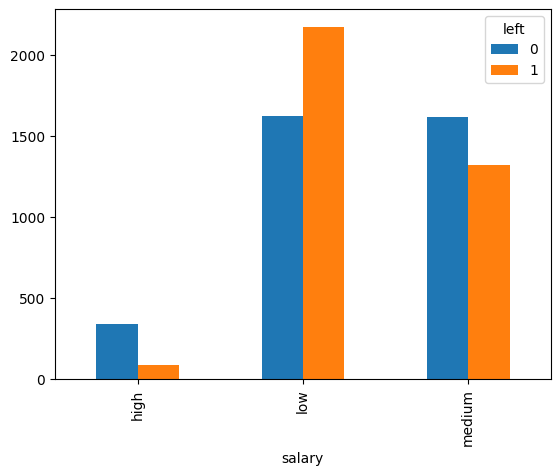

In [29]:
# Impact of salary on employee retention
pd.crosstab(df.salary, df.left).plot(kind="bar")

In [30]:
# Above bar chart shows employees with high salaries are likely to not leave the company

<Axes: xlabel='Department'>

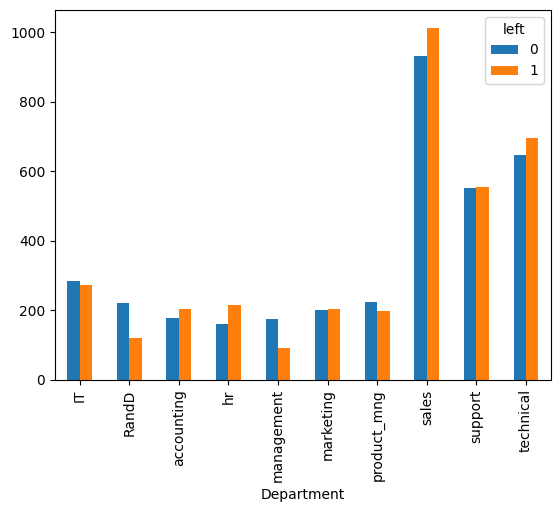

In [32]:
# Department wise employee retention rate
pd.crosstab(df.Department, df.left).plot(kind="bar")

In [33]:
"""
From the data analysis so far we can conclude that we will use following variables as independant variables in our model
**Satisfaction Level**
**Average Monthly Hours**
**Promotion Last 5 Years**
**Salary**
"""

'\nFrom the data analysis so far we can conclude that we will use following variables as independant variables in our model\n**Satisfaction Level**\n**Average Monthly Hours**\n**Promotion Last 5 Years**\n**Salary**\n'

In [34]:
sub_df = df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
sub_df.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [36]:
# Get dummy varibales for salaries
salary_dummies = pd.get_dummies(sub_df.salary, prefix="salary")
salary_dummies.head()

,salary_high,salary_low,salary_medium
0,False,True,False
1,False,False,True
2,False,False,True
3,False,True,False
4,False,True,False


In [37]:
sub_df  = pd.concat([sub_df, salary_dummies], axis="columns")
sub_df.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [41]:
# Salary dummy variables has been added now we can drop salary column
# sub_df = sub_df.drop("salary", axis="columns")


In [42]:
sub_df.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [43]:
# Separating features and targets
X = sub_df
Y = df.left

In [44]:
X.shape, Y.shape

((7142, 6), (7142,))

In [45]:
# Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [46]:
model = LogisticRegression()

In [47]:
# Training the model
model.fit(X_train, y_train)

LogisticRegression()

In [48]:
model.score(X_train, y_train)

0.719061788902503